In [1]:
include("../src/main.jl")


main (generic function with 1 method)

In [2]:
#dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
dump_filepath = "../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"
#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

"../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
#TODO: put this in reading file
const N1 = 288
const N2 = 128
const N3 = 128

const METRIC = "MKS" #FMKS or MKS TODO: prob have to be read from file
const trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (1.444444)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1.0 #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.0
const startx::MVec4 = [0, 1.635684465252566e-01, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1,  6.907755278982137, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [4]:
include("../src/main.jl");
const simulation_data = load_data(dump_filepath, trat_large);

Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [5]:
#Analytic parameters

#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 163.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 80
const pixels_x = 80
const pixels_y = 80
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file "This one is from mario's file"

const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0


0.0

In [6]:
# --- Cell 1: Compute Geodesics for perturbed angles ---

# 1. Define the two angles (in degrees, as per the notebook standard)
th_base = 60.0
epsilon = 1e-6
th1 = th_base - epsilon
th2 = th_base + epsilon

# 2. Update Camera Positions for both angles
# The camera position depends on 'th', so we must recalculate it for both cases.
# Note: We reuse the other parameters (ro, phi, bhspin, Rout) defined earlier in your notebook.
Xcamera1 = MVec4(camera_position(ro, th1, phi, bhspin, Rout))
Xcamera2 = MVec4(camera_position(ro, th2, phi, bhspin, Rout))

# 3. Compute Geodesics for both cases
println("Computing geodesics for th = $th1 ...")
trajectory1 = CalculateGeodesics(Xcamera1, fovx, fovy, freq, 15000, pixels_x, pixels_y, bhspin, Rout, Rstop)

println("Computing geodesics for th = $th2 ...")
trajectory2 = CalculateGeodesics(Xcamera2, fovx, fovy, freq, 15000, pixels_x, pixels_y, bhspin, Rout, Rstop)

println("Done.")

Computing geodesics for th = 59.999999 ...
Computing geodesics for th = 60.000001 ...
Done.


In [36]:
# --- Cell 2: Find the pixel where geodesics differ the most ---

using LinearAlgebra

max_diff = 0.0
best_pixel = (1, 1)

# Helper function to get Cartesian point from internal coordinates X
function get_endpoint_cartesian(X)
    # Using the transformation logic provided
    # r and th come from bl_coord, phi is 2pi * X[4]
    coords = bl_coord(X)
    r = coords[1]
    th = coords[2]
    # If bl_coord returns phi as 3rd element, you could use it, 
    # but we follow your text instructions: phi = 2pi * X[4]
    phi = 2π * X[4] 
    
    x = r * sin(th) * cos(phi)
    y = r * sin(th) * sin(phi)
    z = r * cos(th)
    return [x, y, z]
end

for i in 1:pixels_x
    for j in 1:pixels_y
        # Access the trajectory struct for this pixel
        traj1 = trajectory1[i, j]
        traj2 = trajectory2[i, j]
        
        # We compare the final points (where they end up)
        # traj is a vector of steps, we take the last one
        if !isempty(traj1) && !isempty(traj2)
            # t.X is the internal coordinate vector
            p1 = get_endpoint_cartesian(traj1[end].X)
            p2 = get_endpoint_cartesian(traj2[end].X)
            
            diff = norm(p1 - p2)
            
            if diff > max_diff
                global max_diff = diff
                global best_pixel = (i, j)
            end
        end
    end
end

println("Maximum spatial difference found: $max_diff")
println("Pixel coordinates with max deviation: $best_pixel")

Maximum spatial difference found: 0.0011412994519279013
Pixel coordinates with max deviation: (40, 32)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/Vn16E/src/scenes.jl:264


Plotting pixel (1, 1)


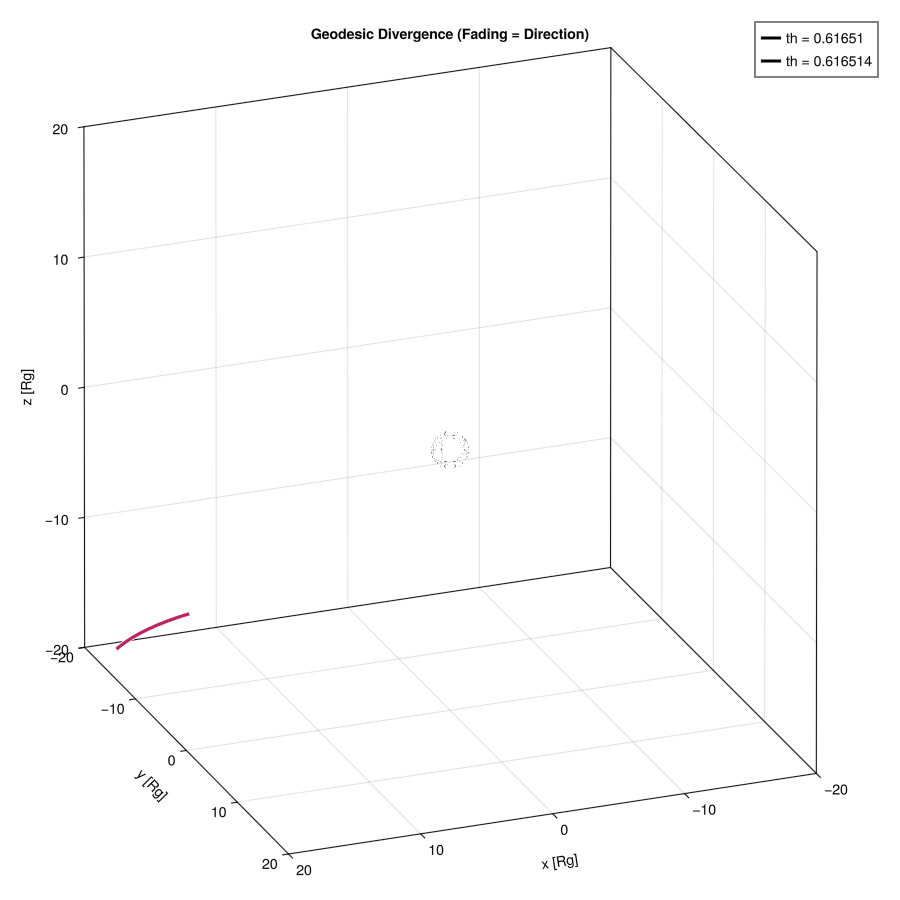

In [34]:
# --- Cell 3: Plot Divergent Geodesics with Fading Trails ---

using GLMakie

# 1. Setup Figure
fig = Figure(resolution = (900, 900))
ax = Axis3(fig[1,1], aspect=(1,1,1), azimuth=1.2, elevation=0.4, 
           title="Geodesic Divergence (Fading = Direction)",
           xlabel="x [Rg]", ylabel="y [Rg]", zlabel="z [Rg]")

# Adjust scale
scale = 20
xlims!(ax, -scale, scale)
ylims!(ax, -scale, scale)
zlims!(ax, -scale, scale)

# 2. BH Sphere Mesh
function sphere_mesh(center, radius, n=30)
    θ = range(0, π, length=n)
    φ = range(0, 2π, length=n)
    xs = Float32[]
    ys = Float32[]
    zs = Float32[]
    for th in θ, ph in φ
        push!(xs, center[1] + radius * sin(th) * cos(ph))
        push!(ys, center[2] + radius * sin(th) * sin(ph))
        push!(zs, center[3] + radius * cos(th))
    end
    return xs, ys, zs
end

xs, ys, zs = sphere_mesh((0.0, 0.0, 0.0), Rh)
mesh!(ax, xs, ys, zs, color=:black, transparency=true)

# 3. Helper to extract points
function get_plot_points(traj)
    pts = Point3f[]
    for t in traj
        coords = bl_coord(t.X)
        r = coords[1]
        th = coords[2]
        phi = 2π * t.X[4]
        
        if r >= Rh
            push!(pts, Point3f(
                r * sin(th) * cos(phi),
                r * sin(th) * sin(phi),
                r * cos(th)
            ))
        end
    end
    return pts
end

# 4. Plot with Colormap Gradient
i_best, j_best = best_pixel
println("Plotting pixel ($i_best, $j_best)")

traj_A = trajectory1[i_best, j_best]
traj_B = trajectory2[i_best, j_best]

pts_A = get_plot_points(traj_A)
pts_B = get_plot_points(traj_B)

# Define gradient colormaps manually using (color, alpha) tuples
# The range 0..1 will map to these gradients
cmap_blue = [(:blue, 0.1), (:blue, 1.0)]
cmap_red  = [(:red, 0.1),  (:red, 1.0)]

# Plot A (Blue)
if !isempty(pts_A)
    # color=1:length maps the index to the colormap (start->end)
    lines!(ax, pts_A, color=1:length(pts_A), colormap=cmap_blue, linewidth=3, label="th = $(round(th1, digits=6))")
    scatter!(ax, pts_A[end], color=:blue, marker=:cross, markersize=20)
end

# Plot B (Red)
if !isempty(pts_B)
    lines!(ax, pts_B, color=1:length(pts_B), colormap=cmap_red, linewidth=3, label="th = $(round(th2, digits=6))")
    scatter!(ax, pts_B[end], color=:red, marker=:cross, markersize=20)
end

axislegend(ax)
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/Vn16E/src/scenes.jl:264


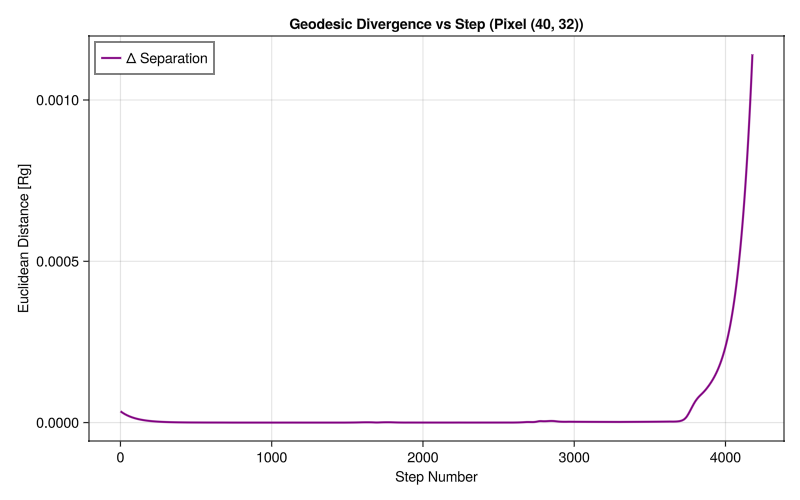

In [46]:
# --- Cell 4: Plot Distance Divergence vs. Step ---

using GLMakie
using LinearAlgebra

# 1. Extract the trajectories for the best pixel
i, j = best_pixel
traj1 = trajectory1[i, j]
traj2 = trajectory2[i, j]

# 2. Determine the number of comparable steps
# We can only compare up to the point where the shorter trajectory ends
n_steps = min(length(traj1), length(traj2))
steps = 1:n_steps
distances = Float64[]

# 3. Calculate Euclidean distance at each step
for k in steps
    # Get the state at step k
    t1 = traj1[k]
    t2 = traj2[k]
    
    # Convert P1 to Cartesian
    c1 = bl_coord(t1.X)
    r1, th1 = c1[1], c1[2]
    phi1 = 2π * t1.X[4]
    p1 = [r1 * sin(th1) * cos(phi1), 
          r1 * sin(th1) * sin(phi1), 
          r1 * cos(th1)]
    
    
    # Convert P2 to Cartesian
    c2 = bl_coord(t2.X)
    r2, th2 = c2[1], c2[2]
    phi2 = 2π * t2.X[4]
    p2 = [r2 * sin(th2) * cos(phi2), 
          r2 * sin(th2) * sin(phi2), 
          r2 * cos(th2)]
    
    # Compute Euclidean distance
    d = norm(p1 - p2)

    push!(distances, d)
end

# 4. Plot the result
fig = Figure(resolution = (800, 500))
ax = Axis(fig[1, 1], 
    title = "Geodesic Divergence vs Step (Pixel $best_pixel)",
    xlabel = "Step Number",
    ylabel = "Euclidean Distance [Rg]",
    # yscale = log10 # Uncomment this if you want to see exponential divergence clearly
)

lines!(ax, steps, distances, color = :purple, linewidth = 2, label = "Δ Separation")

axislegend(ax, position = :lt)
fig